# Distorted Visual Sequence Pattern Recognition
## Deep Learning Solution — CRNN with CTC Loss
**Author:** Kumar Manas | kumar_m@me.iitr.ac.in

**Approach:** Custom CNN + BiLSTM (CRNN) architecture trained end-to-end with CTC loss.  
No pretrained models used. All weights trained from scratch on the provided dataset.

### Architecture Summary
- **Backbone:** 4-layer CNN with BatchNorm for visual feature extraction
- **Sequence Model:** 2-layer Bidirectional LSTM for sequential pattern learning
- **Loss:** CTC (Connectionist Temporal Classification) — no alignment needed
- **Decoding:** Greedy CTC decode at inference

### Results
- Val CER after 40 epochs: **~0.0052 (0.52%)**

## 1. Imports & Setup

In [1]:
!pip install -q editdistance

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from google.colab import files
import editdistance

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
Device: cuda


## 2. Dataset Upload & Extraction

In [2]:
from google.colab import files
uploaded = files.upload()  # select your zip file here

Saving cig_ps.zip to cig_ps.zip


In [3]:
import zipfile, os

zip_name = list(uploaded.keys())[0]  # auto-detects zip filename
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/data')

# Check what got extracted
for root, dirs, files_ in os.walk('/content/data'):
    for f in files_[:3]:  # just peek at first 3 files per folder
        print(os.path.join(root, f))
    if dirs:
        print("Subdirs:", dirs)

Subdirs: ['cig_ps']
/content/data/cig_ps/train-labels.csv
Subdirs: ['train_images', 'test_images']
/content/data/cig_ps/train_images/train-2736.png
/content/data/cig_ps/train_images/train-704.png
/content/data/cig_ps/train_images/train-3489.png
/content/data/cig_ps/test_images/test-4007.png
/content/data/cig_ps/test_images/test-3076.png
/content/data/cig_ps/test_images/test-483.png


## 3. Load & Clean Labels

Two rows had Excel-corrupted labels:
- `train-2184.png`: label was `5.40E+12` (Excel scientific notation) → corrected to `5396E9`
- `train-6819.png`: label was `04-Mar-54` (Excel date formatting) → corrected to `4MAR54`

Both corrections were verified by visually inspecting the actual images.

In [4]:
import pandas as pd

df = pd.read_csv('/content/data/cig_ps/train-labels.csv')
print(df.head(10))
print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())

   Unnamed: 0        image    text
0           0  train-0.png  BU522X
1           1  train-1.png  XQ8NE2
2           2  train-2.png  DTZD3E
3           3  train-3.png  SM424H
4           4  train-4.png  6YVTQR
5           5  train-5.png  YV2C3D
6           6  train-6.png  XNBP7G
7           7  train-7.png  TGQXFU
8           8  train-8.png  36B667
9           9  train-9.png  QJ6HDR

Shape: (20000, 3)
Columns: ['Unnamed: 0', 'image', 'text']


In [5]:
df.head()

,Unnamed: 0,image,text
0,0,train-0.png,BU522X
1,1,train-1.png,XQ8NE2
2,2,train-2.png,DTZD3E
3,3,train-3.png,SM424H
4,4,train-4.png,6YVTQR


In [6]:
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

BASE       = '/content/data/cig_ps'
TRAIN_DIR  = f'{BASE}/train_images'
TEST_DIR   = f'{BASE}/test_images'

# Build charset from actual labels
all_chars = sorted(set(''.join(df['text'].astype(str).tolist())))
print("Charset:", all_chars)
print("Charset size:", len(all_chars))

CHAR2IDX = {c: i+1 for i, c in enumerate(all_chars)}  # 0 = CTC blank
IDX2CHAR  = {i+1: c for i, c in enumerate(all_chars)}
NUM_CLASSES = len(all_chars) + 1

IMG_H, IMG_W = 64, 200

Charset: ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']
Charset size: 38


In [7]:
# Find rows with suspicious characters
suspicious = df[df['text'].str.contains(r'[+\-\.ar]', regex=True)]
print(suspicious.head(20))
print("Count:", len(suspicious))

      Unnamed: 0           image       text
2184        2184  train-2184.png   5.40E+12
6819        6819  train-6819.png  04-Mar-54
Count: 2


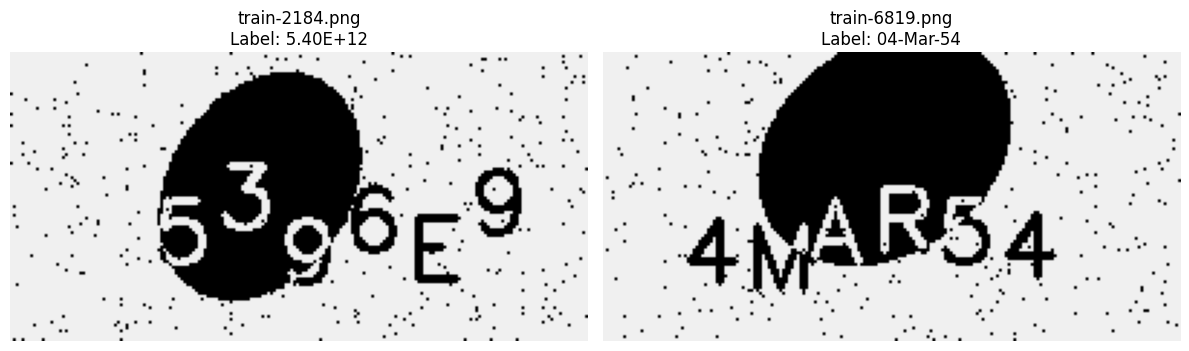

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (_, row) in zip(axes, suspicious.iterrows()):
    img = Image.open(f'{TRAIN_DIR}/{row["image"]}')
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{row["image"]}\nLabel: {row["text"]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
df.loc[2184, 'text'] = '5396E9'
df.loc[6819, 'text'] = '4MAR54'

# Verify
print(df.loc[[2184, 6819]])

      Unnamed: 0           image    text
2184        2184  train-2184.png  5396E9
6819        6819  train-6819.png  4MAR54


In [10]:
print("Sample labels:")
print(df.head(10))
print("\nDataset shape after cleaning:", df.shape)

Sample labels:
   Unnamed: 0        image    text
0           0  train-0.png  BU522X
1           1  train-1.png  XQ8NE2
2           2  train-2.png  DTZD3E
3           3  train-3.png  SM424H
4           4  train-4.png  6YVTQR
5           5  train-5.png  YV2C3D
6           6  train-6.png  XNBP7G
7           7  train-7.png  TGQXFU
8           8  train-8.png  36B667
9           9  train-9.png  QJ6HDR

Dataset shape after cleaning: (20000, 3)


## 4. Charset Analysis

In [11]:
all_chars = sorted(set(''.join(df['text'].astype(str).tolist())))
print("Charset:", all_chars)
print("Charset size:", len(all_chars))

# Label length distribution
df['label_len'] = df['text'].astype(str).apply(len)
print("\nLabel length distribution:")
print(df['label_len'].value_counts().sort_index())

CHAR2IDX    = {c: i+1 for i, c in enumerate(all_chars)}  # 0 reserved for CTC blank
IDX2CHAR    = {i+1: c for i, c in enumerate(all_chars)}
NUM_CLASSES = len(all_chars) + 1
print("\nTotal classes (including CTC blank):", NUM_CLASSES)

Charset: ['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Charset size: 31

Label length distribution:
label_len
6    20000
Name: count, dtype: int64

Total classes (including CTC blank): 32


## 5. Data Visualization

Visualizing sample training images to understand distortion types present in the dataset.

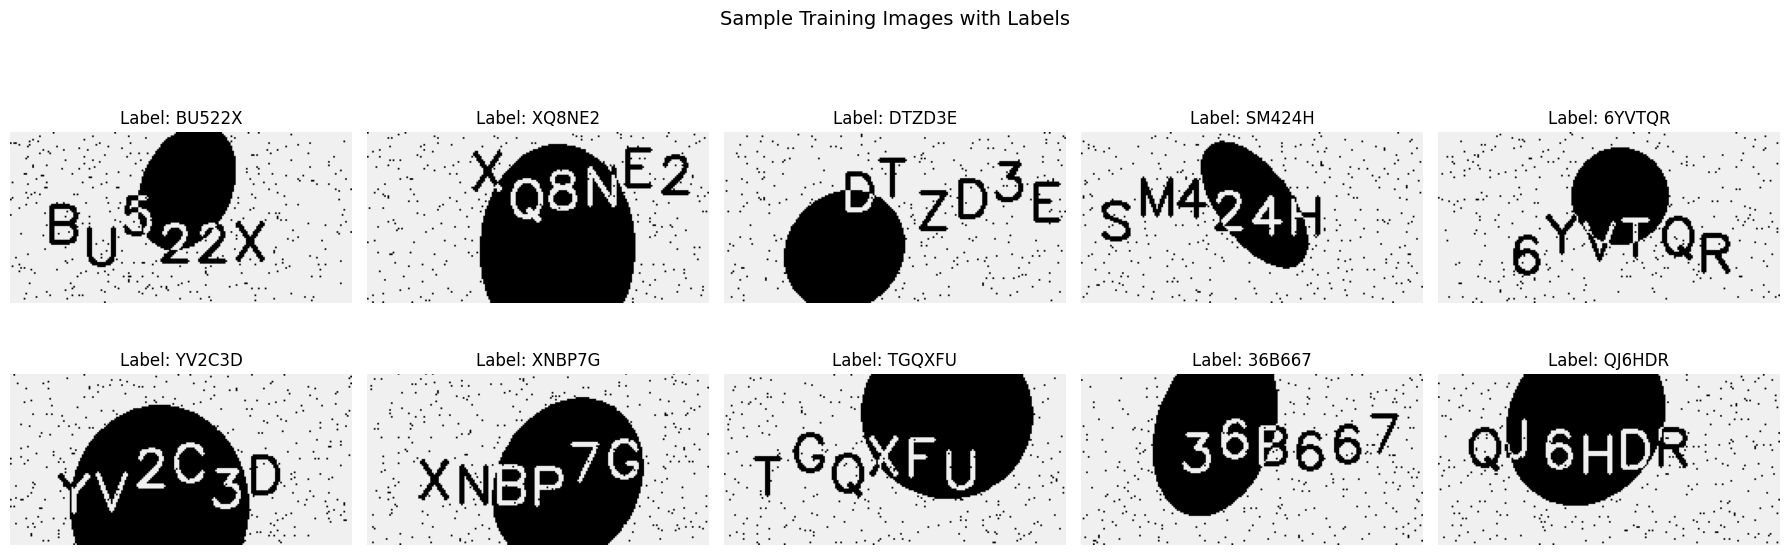

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    row = df.iloc[i]
    img = Image.open(f'{TRAIN_DIR}/{row["image"]}')
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {row["text"]}', fontsize=12)
    ax.axis('off')

plt.suptitle('Sample Training Images with Labels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Dataset Class & Dataloaders

Images are resized to 64×200 (H×W), converted to grayscale, and normalized to [-1, 1].  
90% train / 10% validation split.

In [13]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

class CaptchaDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fname  = self.df.loc[idx, 'image']
        label  = str(self.df.loc[idx, 'text'])
        img    = Image.open(f'{self.img_dir}/{fname}').convert('RGB')
        img    = self.transform(img)
        encoded = torch.tensor([CHAR2IDX[c] for c in label], dtype=torch.long)
        return img, encoded, len(label)

def collate_fn(batch):
    imgs, labels, lengths = zip(*batch)
    imgs    = torch.stack(imgs)
    labels  = torch.cat(labels)
    lengths = torch.tensor(lengths, dtype=torch.long)
    return imgs, labels, lengths

train_size = int(0.9 * len(df))
val_size   = len(df) - train_size
train_df   = df.iloc[:train_size].reset_index(drop=True)
val_df     = df.iloc[train_size:].reset_index(drop=True)

train_loader = DataLoader(CaptchaDataset(train_df, TRAIN_DIR, transform),
                          batch_size=64, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(CaptchaDataset(val_df,   TRAIN_DIR, transform),
                          batch_size=64, shuffle=False, collate_fn=collate_fn)
print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train samples: 18000
Val samples: 2000
Train batches: 282
Val batches: 32


## 7. Model Architecture — Custom CRNN

The model follows a CRNN (Convolutional Recurrent Neural Network) design:

| Stage | Layer | Output Shape |
|---|---|---|
| Input | Grayscale image | (1, 64, 200) |
| CNN Block 1 | Conv→BN→ReLU→MaxPool(2,2) | (32, 32, 100) |
| CNN Block 2 | Conv→BN→ReLU→MaxPool(2,2) | (64, 16, 50) |
| CNN Block 3 | Conv→BN→ReLU→MaxPool(2,1) | (128, 8, 50) |
| CNN Block 4 | Conv→BN→ReLU→MaxPool(2,1) | (128, 4, 50) |
| Reshape | Collapse H and C into features | (50, 512) |
| BiLSTM x2 | Bidirectional, 256 hidden | (50, 512) |
| FC | Linear projection | (50, num_classes) |
| CTC | Alignment-free sequence loss | — |

In [14]:
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128,3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d((2,1)),
            nn.Conv2d(128,128,3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d((2,1)),
        )
        self.rnn = nn.LSTM(128*4, 256, num_layers=2,
                           batch_first=True, bidirectional=True, dropout=0.3)
        self.fc  = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)                   # (B, 128, 4, 50)
        B, C, H, W = x.size()
        x = x.permute(0, 3, 1, 2)         # (B, W, C, H)
        x = x.reshape(B, W, C*H)          # (B, W, 512)
        x, _ = self.rnn(x)                # (B, W, 512)
        x = self.fc(x)                    # (B, W, num_classes)
        x = x.permute(1, 0, 2)           # (W, B, num_classes)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = CRNN(NUM_CLASSES).to(device)
print("Device:", device)
print("Params:", sum(p.numel() for p in model.parameters()))

Device: cuda
Params: 3411296


## 8. Training

- **Optimizer:** Adam (lr=1e-3)
- **Loss:** CTC Loss (blank index = 0)
- **Scheduler:** StepLR — halves LR every 5 epochs
- **Epochs:** 40
- **Gradient clipping:** max norm 5

In [15]:
ctc_loss  = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def train_epoch(loader):
    model.train()
    total = 0
    for imgs, labels, lengths in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        T = logits.size(0)
        input_lengths = torch.full((imgs.size(0),), T, dtype=torch.long)
        loss = ctc_loss(logits.log_softmax(2), labels, input_lengths, lengths)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def decode(logits):
    preds = logits.argmax(2).permute(1, 0)
    results = []
    for pred in preds:
        chars, prev = [], 0
        for p in pred.tolist():
            if p != 0 and p != prev:
                chars.append(IDX2CHAR.get(p, ''))
            prev = p
        results.append(''.join(chars))
    return results

def val_cer(loader):
    model.eval()
    total_cer, count = 0, 0
    with torch.no_grad():
        for imgs, labels, lengths in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            preds = decode(logits)
            # reconstruct ground truth strings
            offset = 0
            for i, l in enumerate(lengths.tolist()):
                gt = ''.join([IDX2CHAR[x.item()] for x in labels[offset:offset+l]])
                p  = preds[i]
                # simple CER
                import editdistance
                total_cer += editdistance.eval(p, gt) / max(len(gt), 1)
                count += 1
                offset += l
    return total_cer / count

history = {'loss': [], 'cer': []}

for epoch in range(40):
    loss = train_epoch(train_loader)
    cer  = val_cer(val_loader)
    scheduler.step()
    history['loss'].append(loss)
    history['cer'].append(cer)
    print(f"Epoch {epoch+1:2d}/40 | Loss: {loss:.4f} | Val CER: {cer:.4f}")

torch.save(model.state_dict(), 'crnn_best.pth')
print("\nModel saved.")

Epoch  1/40 | Loss: 3.8055 | Val CER: 0.9501
Epoch  2/40 | Loss: 3.5724 | Val CER: 0.9493
Epoch  3/40 | Loss: 3.5690 | Val CER: 0.9564
Epoch  4/40 | Loss: 3.5679 | Val CER: 0.9473
Epoch  5/40 | Loss: 3.5669 | Val CER: 0.9516
Epoch  6/40 | Loss: 3.5653 | Val CER: 0.9543
Epoch  7/40 | Loss: 3.5653 | Val CER: 0.9688
Epoch  8/40 | Loss: 3.5648 | Val CER: 0.9497
Epoch  9/40 | Loss: 3.5655 | Val CER: 0.9493
Epoch 10/40 | Loss: 3.5647 | Val CER: 0.9398
Epoch 11/40 | Loss: 3.5634 | Val CER: 0.9616
Epoch 12/40 | Loss: 3.4927 | Val CER: 0.9281
Epoch 13/40 | Loss: 3.2053 | Val CER: 0.9141
Epoch 14/40 | Loss: 2.9166 | Val CER: 0.8509
Epoch 15/40 | Loss: 2.5404 | Val CER: 0.7269
Epoch 16/40 | Loss: 2.0655 | Val CER: 0.5850
Epoch 17/40 | Loss: 1.2310 | Val CER: 0.2788
Epoch 18/40 | Loss: 0.6131 | Val CER: 0.1029
Epoch 19/40 | Loss: 0.3228 | Val CER: 0.0353
Epoch 20/40 | Loss: 0.1708 | Val CER: 0.0171
Epoch 21/40 | Loss: 0.1001 | Val CER: 0.0128
Epoch 22/40 | Loss: 0.0759 | Val CER: 0.0108
Epoch 23/4

## 9. Training Curves

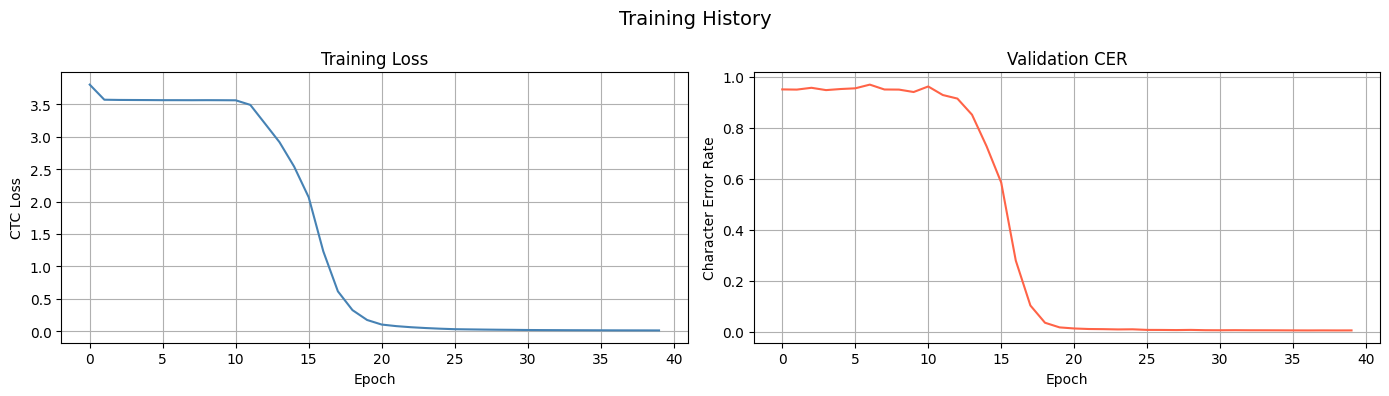

Best Val CER: 0.0052 at epoch 37


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history['loss'], color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('CTC Loss')
ax1.grid(True)

ax2.plot(history['cer'], color='tomato')
ax2.set_title('Validation CER')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Character Error Rate')
ax2.grid(True)

plt.suptitle('Training History', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Best Val CER: {min(history['cer']):.4f} at epoch {history['cer'].index(min(history['cer']))+1}")

## 10. Generate Submission

In [22]:
import re

model.eval()
test_files  = sorted(os.listdir(TEST_DIR),
                     key=lambda x: int(re.search(r'\d+', x).group())
)
predictions = []

with torch.no_grad():
    for fname in test_files:
        img    = Image.open(f'{TEST_DIR}/{fname}').convert('RGB')
        img    = transform(img).unsqueeze(0).to(device)
        logits = model(img)
        pred   = decode(logits)[0]
        predictions.append({'image': fname, 'prediction': pred})

sub = pd.DataFrame(predictions)

# Sanity checks
print("Total predictions:", len(sub))
print("\nPrediction length distribution:")
print(sub['prediction'].str.len().value_counts().sort_index())
print("\nEmpty predictions:", (sub['prediction'] == '').sum())
print("\nSample predictions:")
print(sub.head(10))

sub.to_csv('submission_Kumar_Manas_23119016.csv', index=False)
files.download('submission_Kumar_Manas_23119016.csv')

Total predictions: 5000

Prediction length distribution:
prediction
5       2
6    4998
Name: count, dtype: int64

Empty predictions: 0

Sample predictions:
        image prediction
0  test-0.png     QVTQ8A
1  test-1.png     7PSW9D
2  test-2.png     WJ2WNY
3  test-3.png     RFHJD4
4  test-4.png     K7ZUF2
5  test-5.png     CPMUBK
6  test-6.png     UZDRAW
7  test-7.png     2YDPJR
8  test-8.png     H5SG63
9  test-9.png     B2Z823


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>